In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

import scanpy.external as sce

In [2]:
# import session_info
# session_info.show()

In [3]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/home/kk837/rfs/rfs-teichlab-nfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

/home/kk837/rfs/rfs-teichlab-nfs-iCNyzSAaucw/kk837/function/python/utils.py:356: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [4]:
sc.settings.set_figure_params(dpi=80)

# Variables

In [5]:
adata_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/subsets'
celltype = 'EpicardialCells'

In [6]:
latent_space = 'pca_harmony'

# Read in data

In [7]:
# read in
adata = sc.read_h5ad(f'{adata_dir}/{celltype}_lognorm.h5ad')
adata

AnnData object with n_obs × n_vars = 4388 × 4387
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_3.

In [8]:
adata.X.data[:5]

array([3.6604488, 3.6604488, 3.6604488, 3.6604488, 3.6604488])

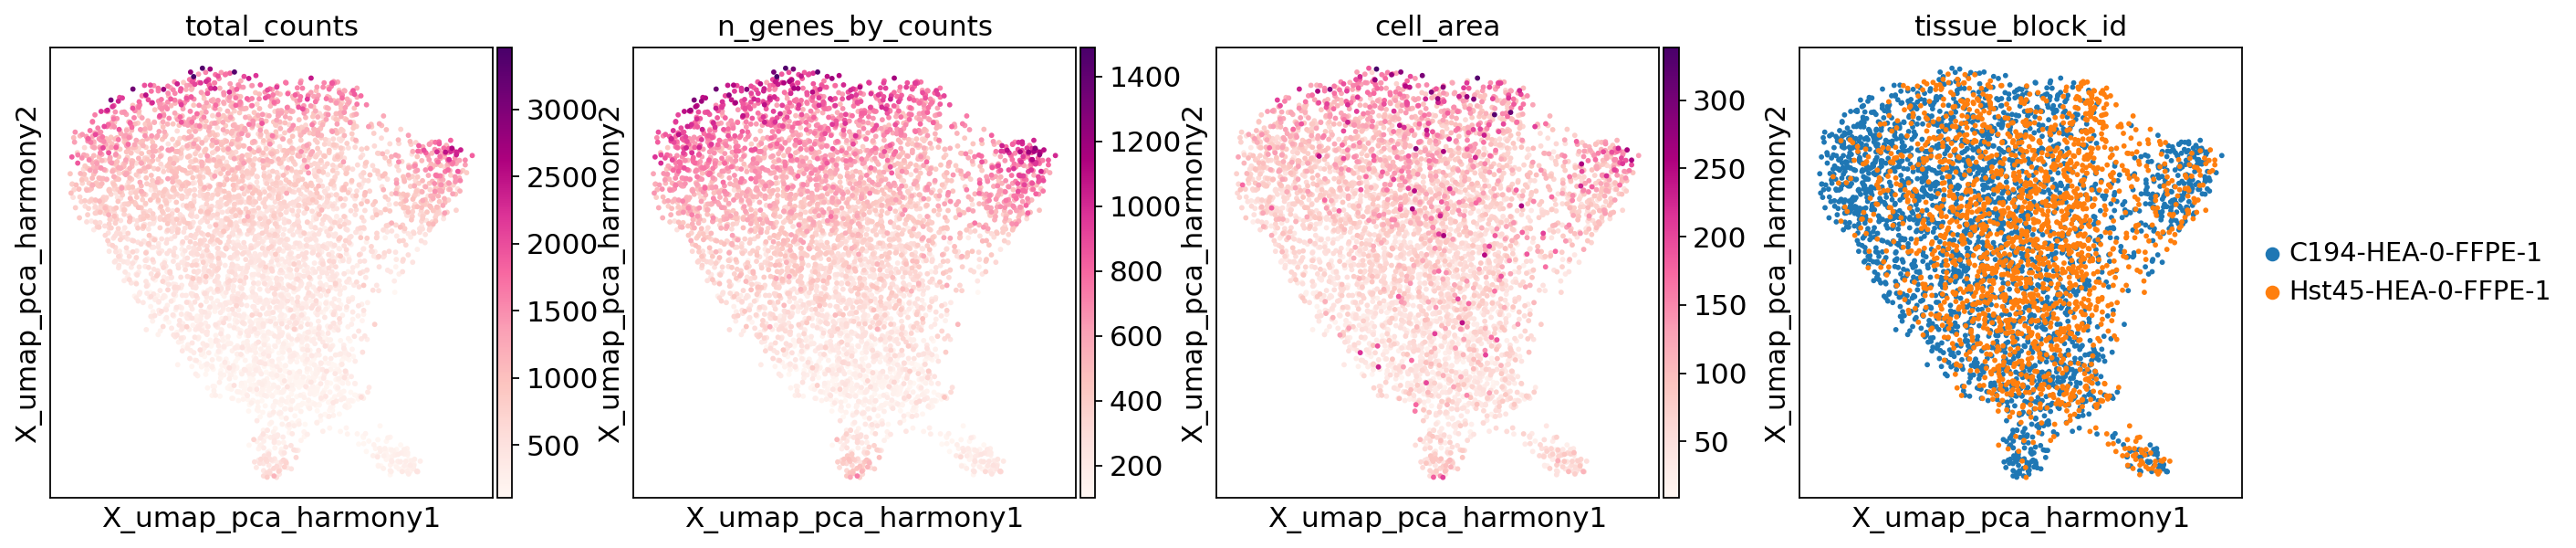

In [9]:
sc.pl.embedding(adata, basis=f"X_umap_{latent_space}",
                color=['total_counts','n_genes_by_counts','cell_area','tissue_block_id'],
                    wspace=0.2,cmap='RdPu',vmax='p100')

In [10]:
%%time
# leiden clustering
resolutions_list = [# 0.2,0.4,0.6,1, # already done
                    1.2,1.5,2,3,4]
for resolution in resolutions_list:
    sc.tl.leiden(adata,neighbors_key=latent_space,
                     resolution=resolution,key_added=f'leiden_{str(resolution)}',n_iterations=2)

<timed exec>:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


CPU times: user 3.42 s, sys: 16.6 ms, total: 3.44 s
Wall time: 3.45 s


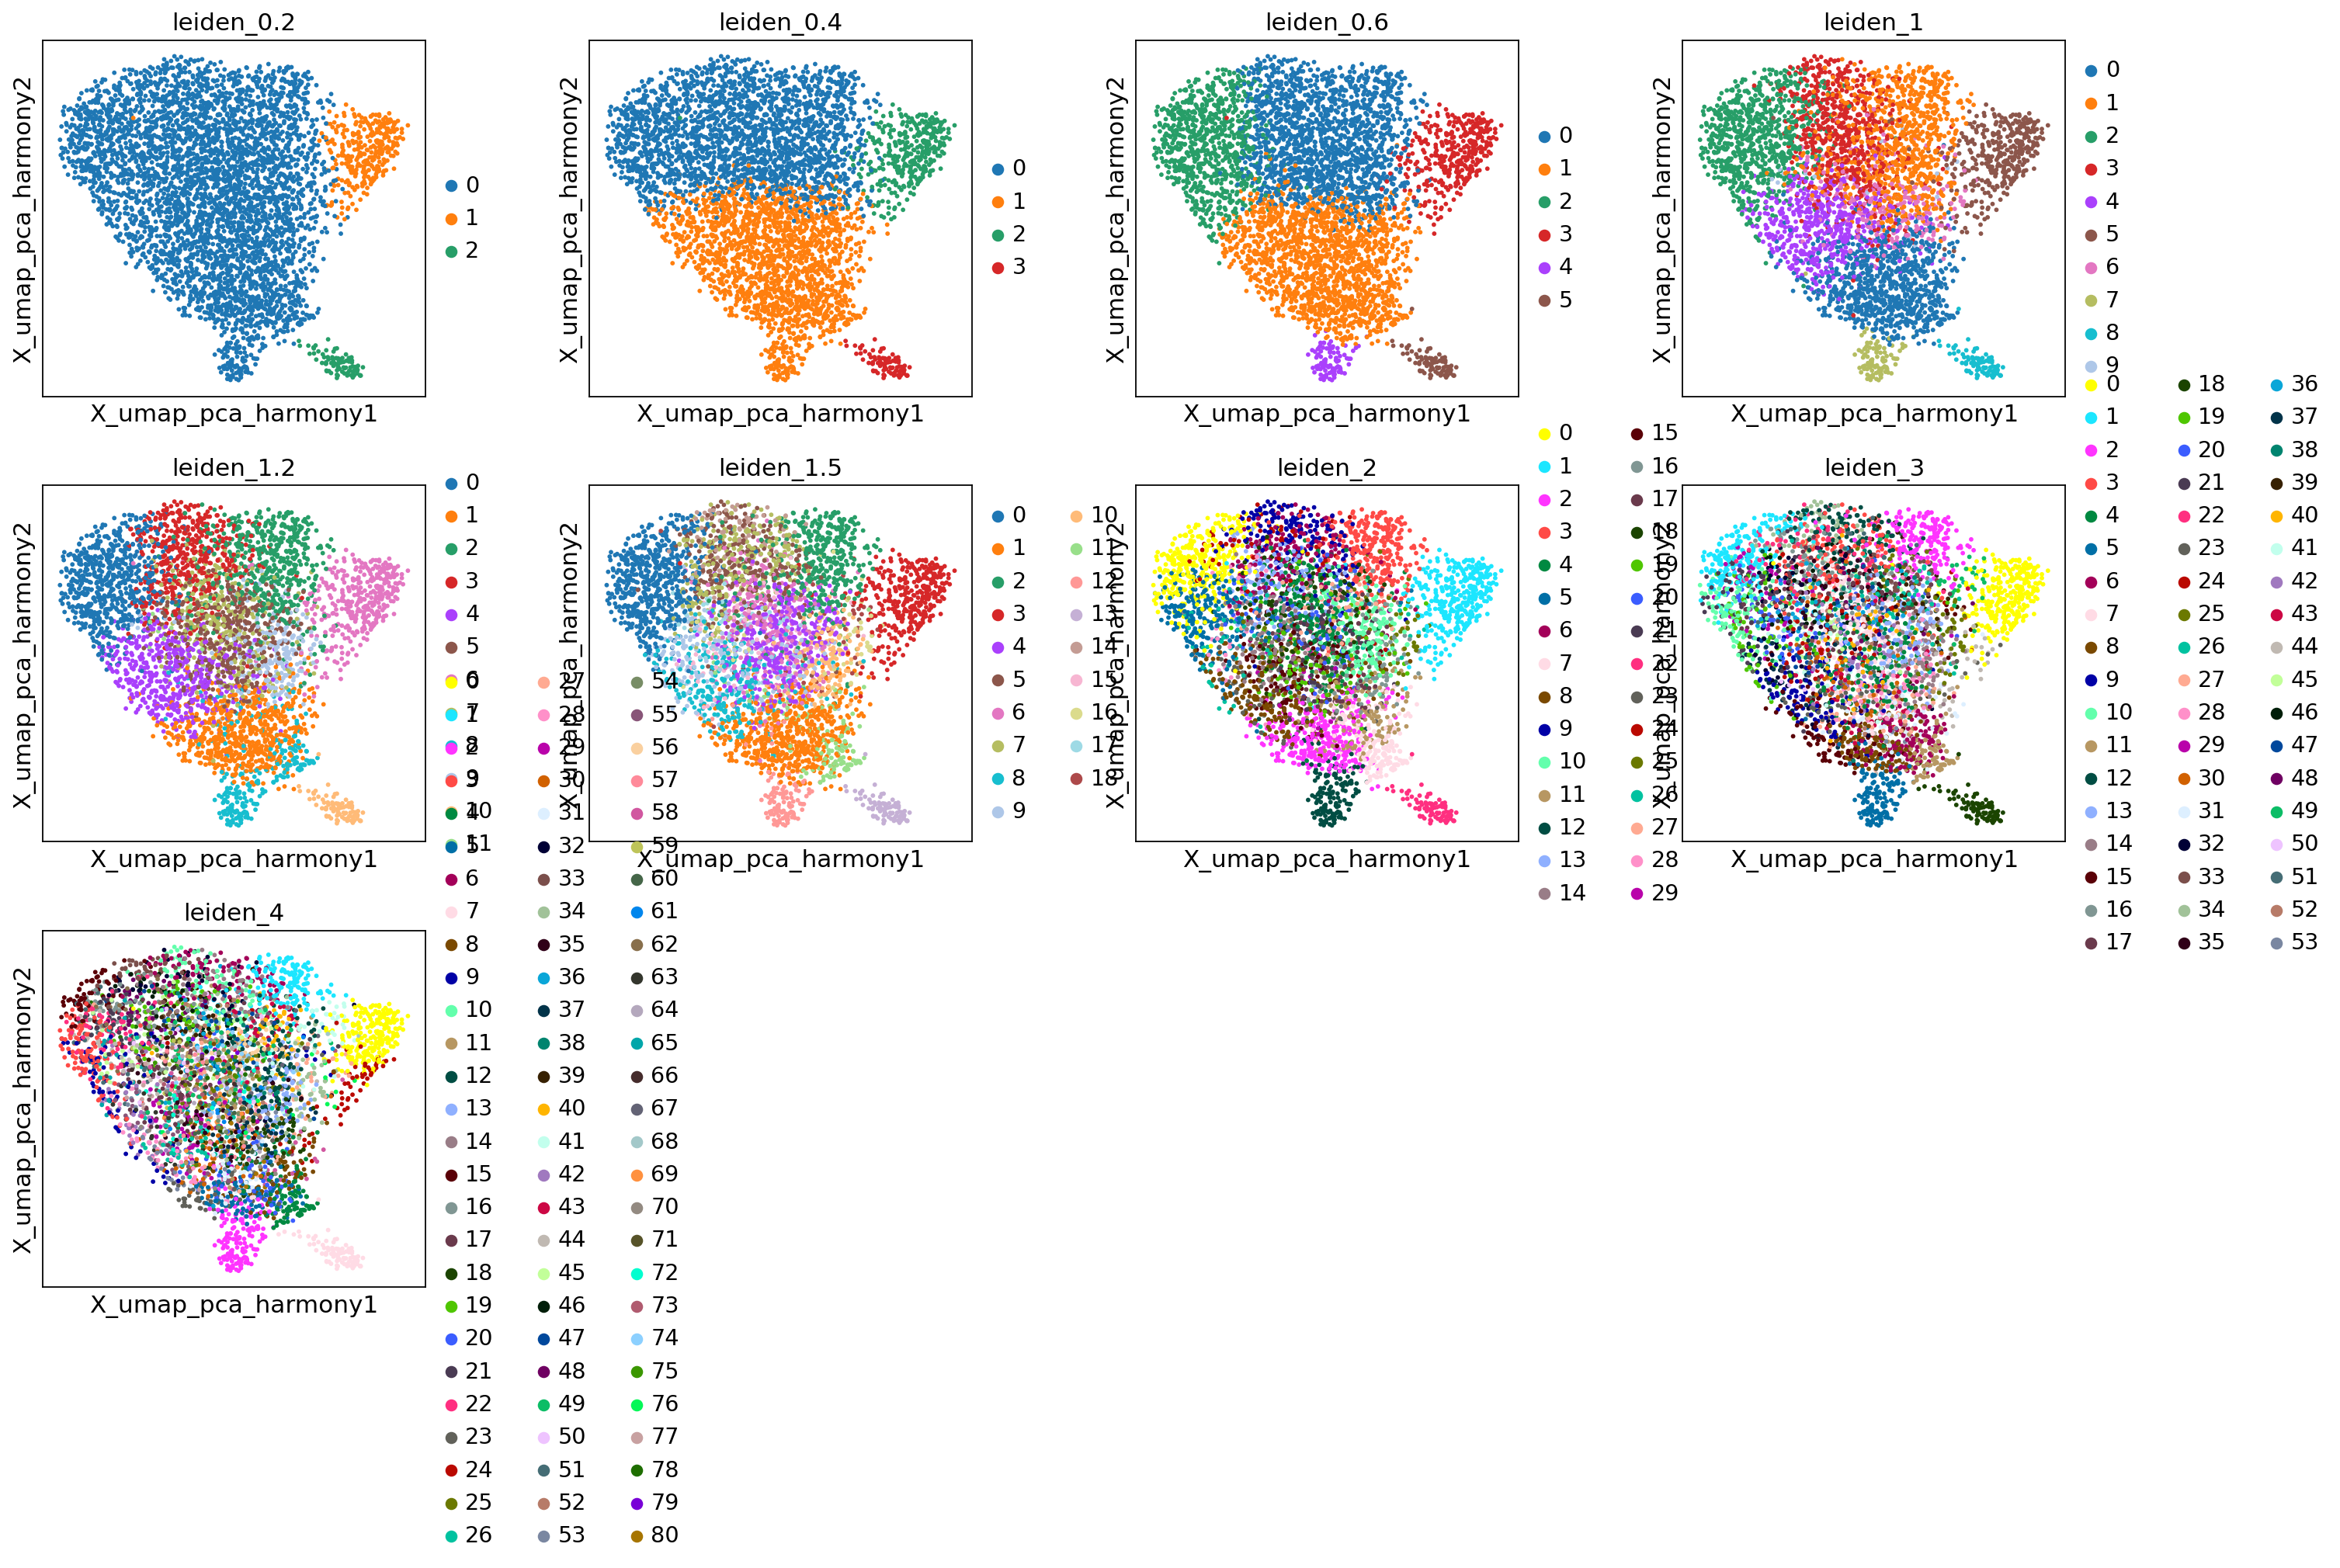

In [11]:
sc.pl.embedding(adata, basis=f"X_umap_{latent_space}",
                color=[f'leiden_{str(resolution)}' for resolution in [0.2,0.4,0.6,1,1.2,1.5,2,3,4]],
                wspace=0.3)

In [16]:
# markers for fine-grained cell types
sc_markers = pd.read_csv(f'/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/VisiumHD/re-seq_mpp0p3/sc_{celltype}_finegrain_markers.csv')
mask1 = sc_markers['group_mean']>0.5
mask2 = sc_markers['logfoldchanges']>0.5
sc_markers = sc_markers[mask1&mask2]

markers = {}
n_top = 10
for c in set(sc_markers['group']):
    markers_sub = sc_markers[sc_markers['group']==c]
    markers_sub.sort_values('logfoldchanges',ascending=False)
    markers[c]=list(markers_sub[:n_top]['names'])

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in adata.var_names]

genes = []
for g in markers.values():
    genes = genes + [x for x in g if (x in adata.var_names)&(x not in genes)]

In [17]:
markers

{'EpicardiumDerivedCells': ['MEG3', 'PMP22'],
 'MesothelialEpicardialCells': ['INMT', 'HMCN1']}

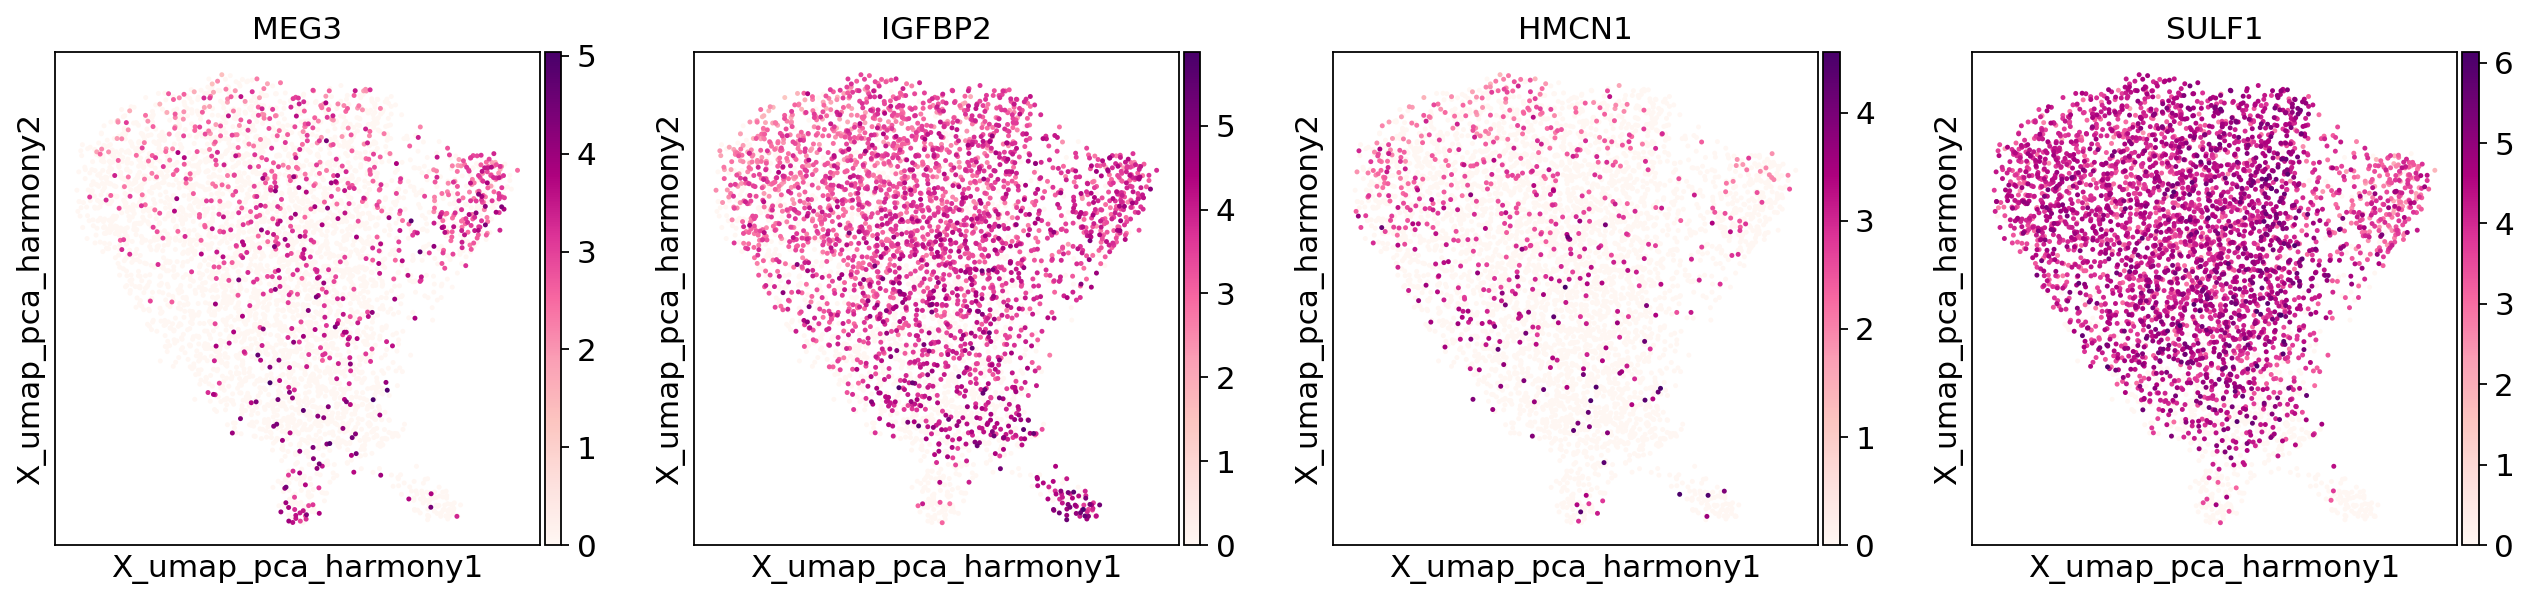

In [15]:
sc.pl.embedding(adata,basis=f"X_umap_{latent_space}",color=genes, size=20,
               ncols=6, wspace=0.2,cmap='RdPu',vmax='p100')

# Select a resolution

In [19]:
resolution_sel = 1

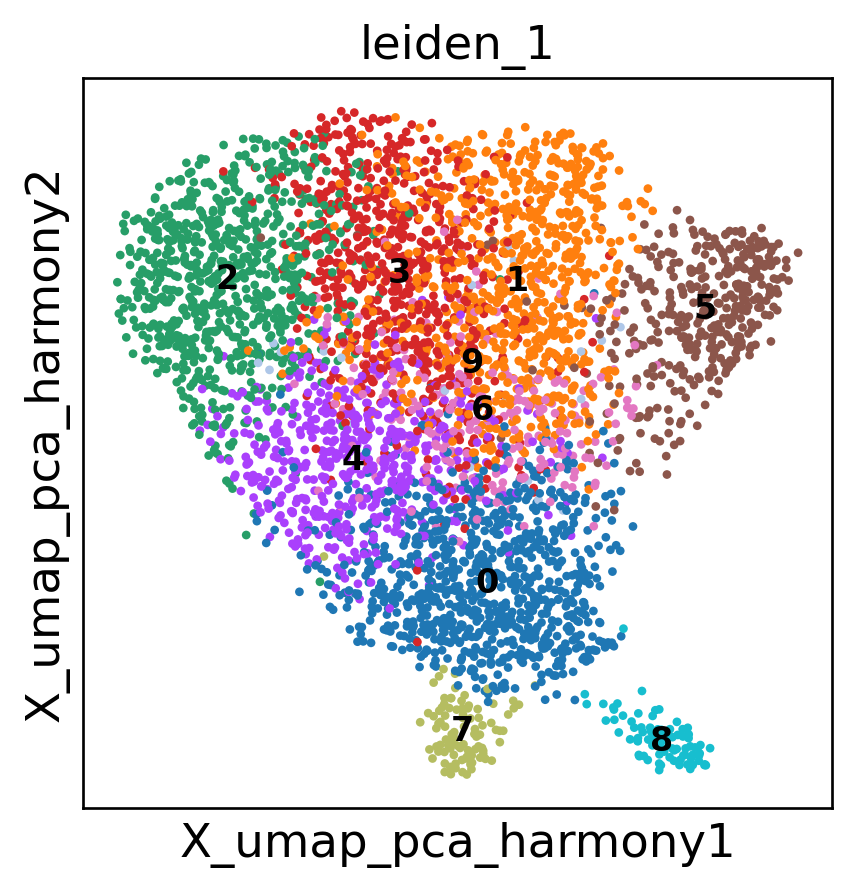

In [20]:
sc.settings.set_figure_params(dpi=120)
sc.pl.embedding(adata,
                    basis=f"X_umap_{latent_space}",
                    color=f'leiden_{str(resolution_sel)}',
                   legend_loc='on data',legend_fontsize=10
                   )
sc.settings.set_figure_params(dpi=80)

categories: 0, 1, 2, etc.
var_group_labels: EpicardiumDerivedCells, MesothelialEpicardialCells


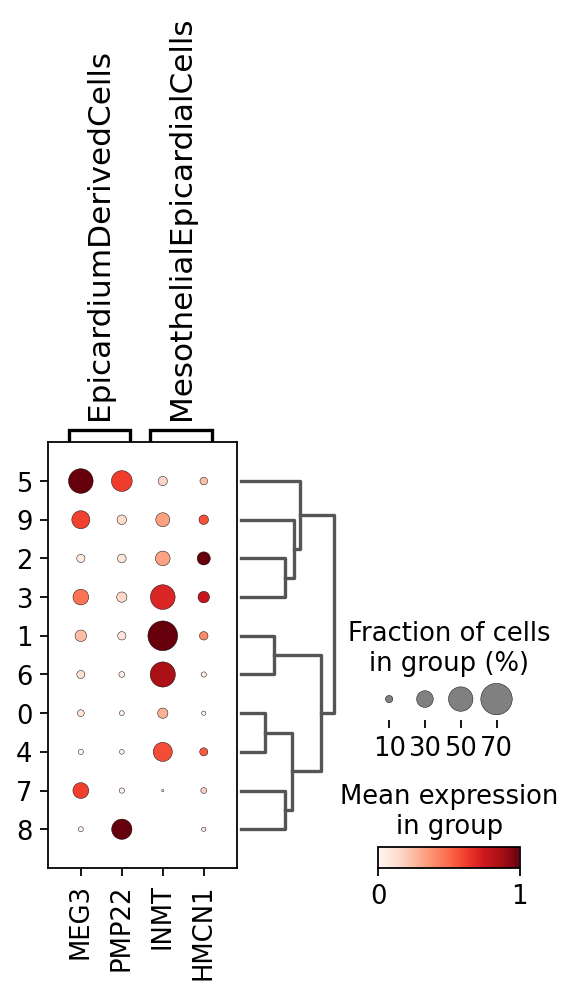

In [21]:
sc.tl.dendrogram(adata,groupby=f'leiden_{str(resolution_sel)}')
sc.pl.dotplot(adata,
              var_names=markers,
              groupby=f'leiden_{str(resolution_sel)}',
              standard_scale='var',
              dendrogram=True
             )

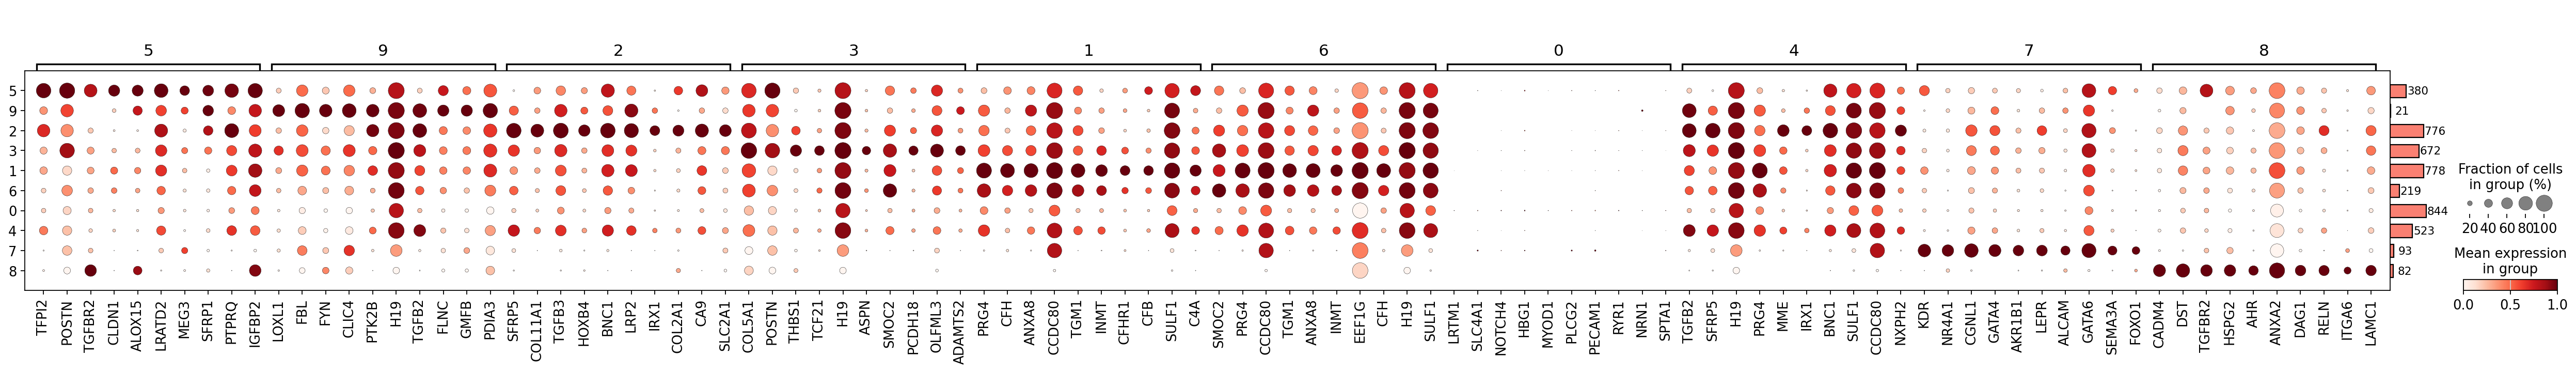

In [22]:
# DEG analysis
adata.uns['log1p']['base']=None
sc.tl.rank_genes_groups(adata,groupby=f'leiden_{str(resolution_sel)}')
sc.tl.dendrogram(adata, groupby=f'leiden_{str(resolution_sel)}')
dp=sc.pl.rank_genes_groups_dotplot(adata, dendrogram=True, standard_scale='var', return_fig=True)
dp.add_totals().show()

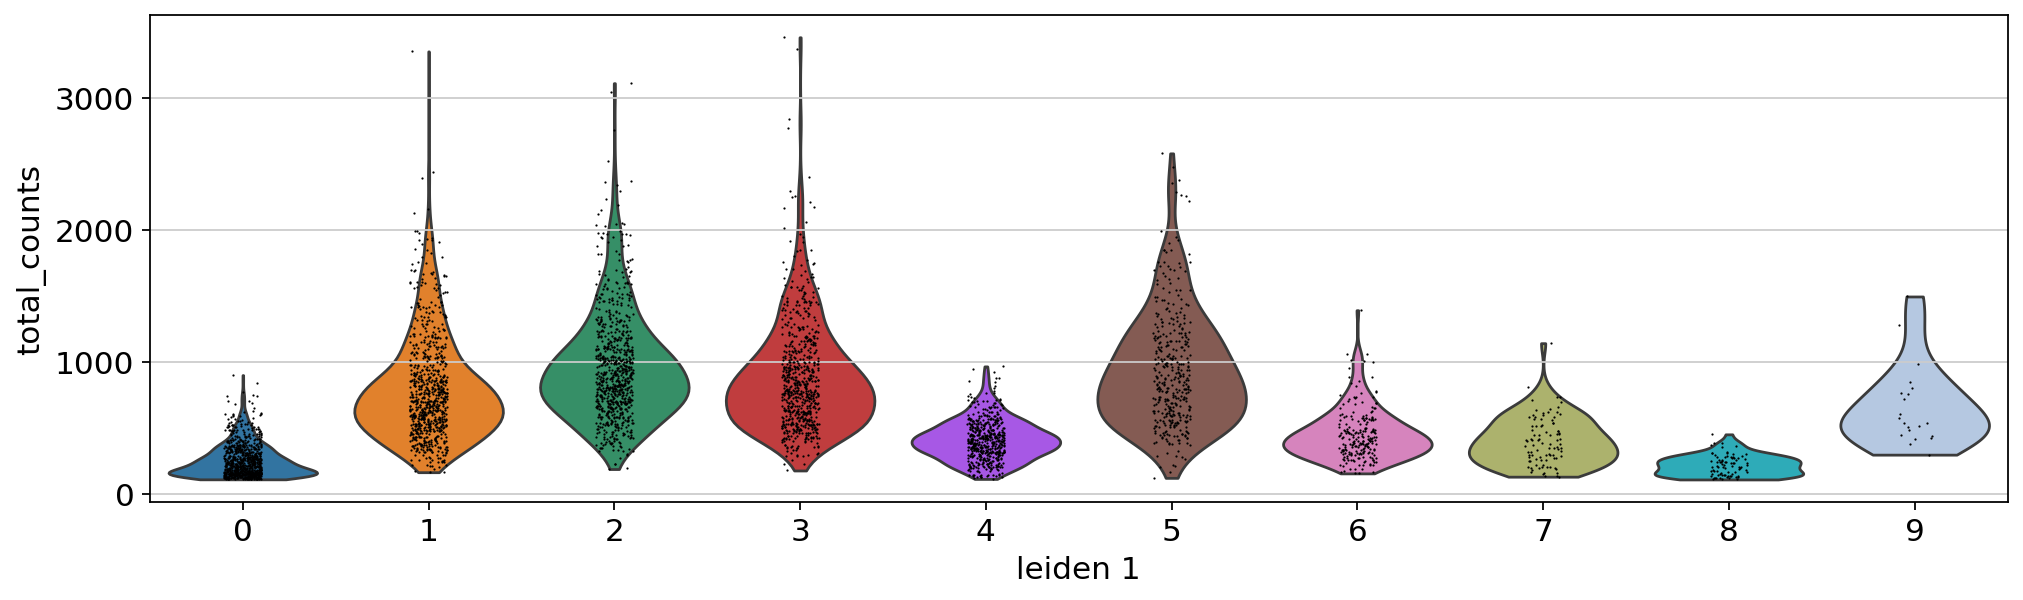

In [23]:
# QC metrices
sc.set_figure_params(figsize=(12, 4))
sc.pl.violin(adata,keys=['total_counts'],groupby=f'leiden_{str(resolution_sel)}')
sc.settings.set_figure_params(dpi=80)

categories: 0, 1, 2, etc.
var_group_labels: CM, vCM, aCM, etc.


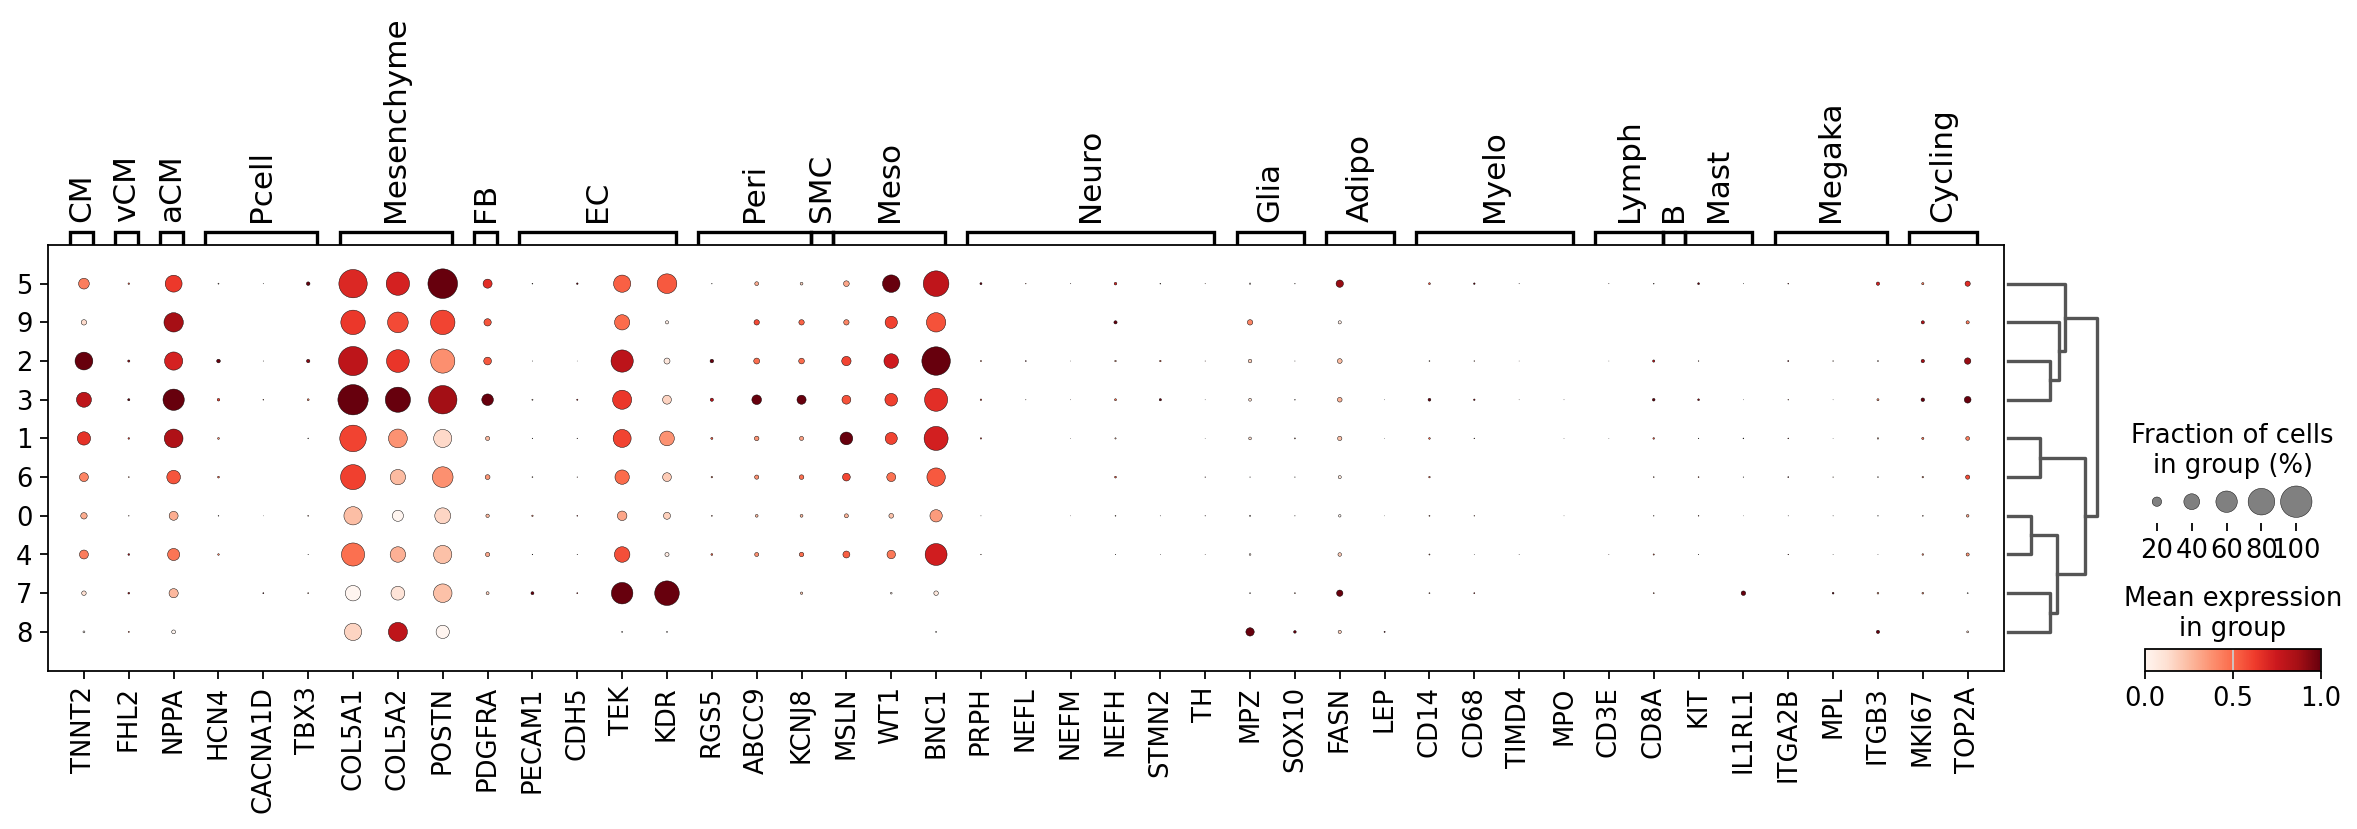

In [24]:
# coarse-grained markers
coarse_markers = {
    'CM': ['TTN', 'TNNT2','MYH6'],
    'vCM': ['MYH7', 'MYL2', 'FHL2'],
    'aCM': ['NPPA', 'MYL7', 'MYL4'],
    'Pcell':['HCN1','HCN4','CACNA1D','TBX3','SHOX2'],
    'Mesenchyme':['COL5A1','COL5A2','POSTN'], # markers in the Xenium5000 panel
    'FB': ['DCN', 'GCN', 'PDGFRA','COL1A1','COL1A2'],
    'EC': ['VWF', 'PECAM1', 'CDH5','RGCC', 'FABP5','TEK','KDR','LYVE1','CCL21'],
    'Peri': ['RGS5', 'ABCC9', 'KCNJ8'],
    'SMC': ['MYH11', 'TAGLN', 'ACTA2'],
    'Meso': ['MSLN', 'WT1', 'BNC1'],
    'Neuro': ['PLP1', 'NRXN1', 'NRXN3','PRPH', 'NEFL', 'NEFM', 'NEFH', 'STMN2', 'SST', 'SLC10A4', 'SLC18A3', 'TH', 'NPY'],
    'Glia':['MPZ','PLP1','SOX10'],
    'Adipo': ['GPAM', 'FASN', 'LEP'],
    'Myelo': ['CD14', 'C1QA', 'CD68','LYVE1','TIMD4','CCR2','MPO'],
    'Lymph': ['CD3E','CD3D','CD8A','IL7R', 'CD40LG','CD19','SDC1','IGHG1','IGHA1'],
    'B': ['CD19','SDC1','IGHG1','IGHA1'],
    'Mast': ['KIT', 'CPA3','HDC','IL1RL1'],
    'Megaka':['ITGA2B','MPL','ITGB3', 'TUBB1', 'PPBP'],
    'Cycling':['MKI67','TOP2A'],
}

for key in coarse_markers.keys():
    coarse_markers[key]=[x for x in coarse_markers[key] if x in adata.var_names]

sc.tl.dendrogram(adata, groupby=f'leiden_{str(resolution_sel)}')
sc.pl.dotplot(adata,
              coarse_markers, 
              groupby=f'leiden_{str(resolution_sel)}',
              dendrogram=True,
              standard_scale="var",
              color_map="Reds",
              swap_axes=False,
             )

# Annotate

In [26]:
# annotate
adata.obs['fine_grain_manual'] = adata.obs[f'leiden_{str(resolution_sel)}'].copy()
adata.obs.replace({'fine_grain_manual':{
    '0':'LowCountsCells',
    '1':'MesothelialEpicardialCells',
    '2':'MesothelialEpicardialCells',
    '3':'MesothelialEpicardialCells',
    '4':'MesothelialEpicardialCells',
    '5':'EpicardiumDerivedCells',
    '6':'MesothelialEpicardialCells',
    '7':'EndocardialCushionCells',
    '8':'unclassified',
    '9':'MesothelialEpicardialCells',
}},inplace=True)
adata.obs['fine_grain_manual'].value_counts()

/tmp/ipykernel_2031645/352026240.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({'fine_grain_manual':{


fine_grain_manual
MesothelialEpicardialCells    2989
LowCountsCells                 844
EpicardiumDerivedCells         380
EndocardialCushionCells         93
unclassified                    82
Name: count, dtype: int64

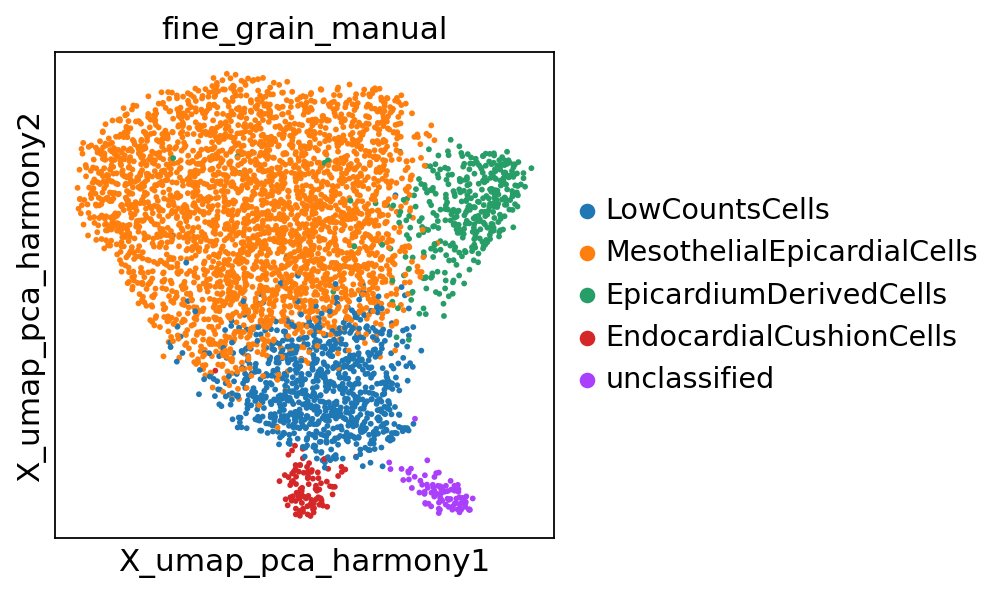

In [27]:
sc.pl.embedding(adata, basis=f"X_umap_{latent_space}",
                color='fine_grain_manual',
                wspace=0.3)

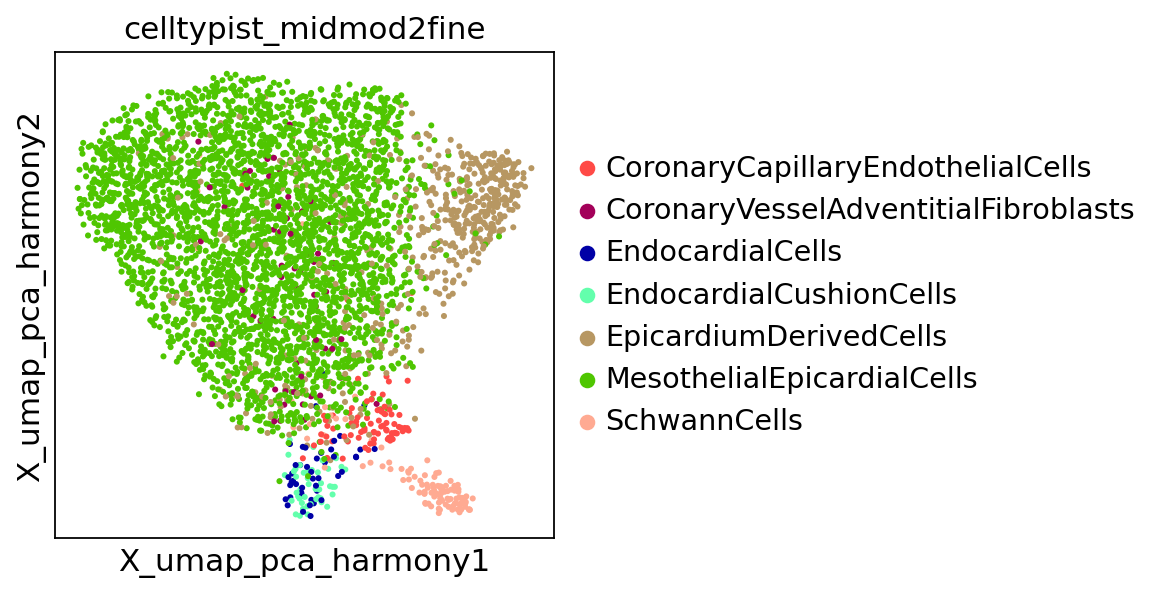

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


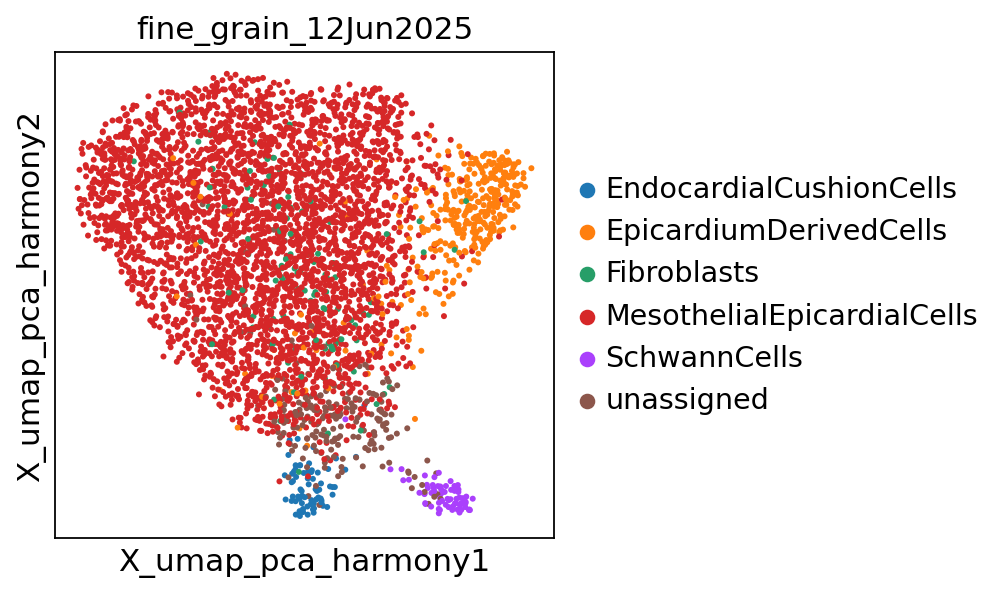

In [28]:
for group_col in ['celltypist_midmod2fine','fine_grain_12Jun2025']:
    val_counts = adata.obs[group_col].value_counts()
    celltype_sel = val_counts.index[val_counts>(adata.shape[0]*0.01)]
    ad = adata[adata.obs[group_col].isin(celltype_sel)]
    sc.pl.embedding(ad,
                        basis=f"X_umap_{latent_space}",
                        color=group_col,
                       )

# Save

In [29]:
# save
adata.write(f'{adata_dir}/{celltype}_lognorm.h5ad')
print(f'{adata_dir}/{celltype}_lognorm.h5ad')

/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/subsets/EpicardialCells_lognorm.h5ad


# Plot on sections

In [30]:
# load original adata with spatial coordinates
adata_ori = sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_celltype-sel_raw.h5ad',
                        backed='r')
adata.obsm['spatial'] = adata_ori[adata.obs_names].obsm['spatial'].copy()

/tmp/ipykernel_2031645/2800704882.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],# groups='SinoatrialNodePacemakerCells',


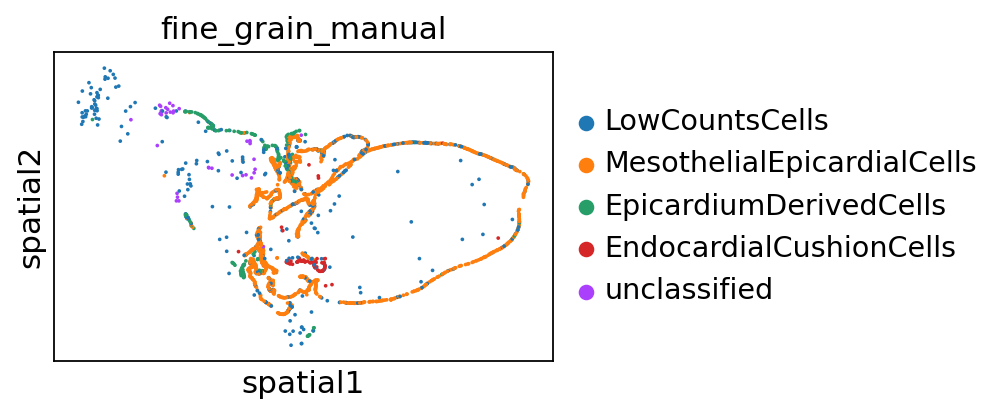

/tmp/ipykernel_2031645/2800704882.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],# groups='SinoatrialNodePacemakerCells',


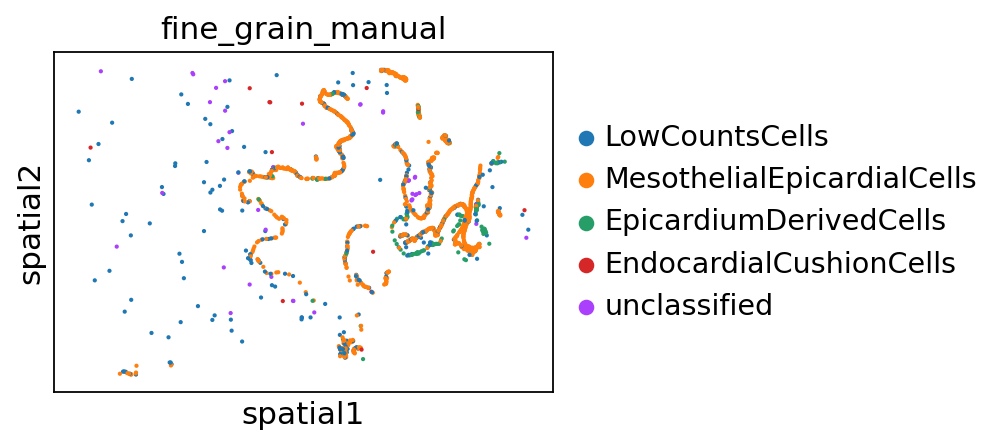

In [33]:
for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
    slide = adata[adata.obs['tissue_block_id']==tissue_id]
    sc.pl.spatial(slide,color=['fine_grain_manual'],# groups='SinoatrialNodePacemakerCells',
                  spot_size=80,vmax='p100')

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


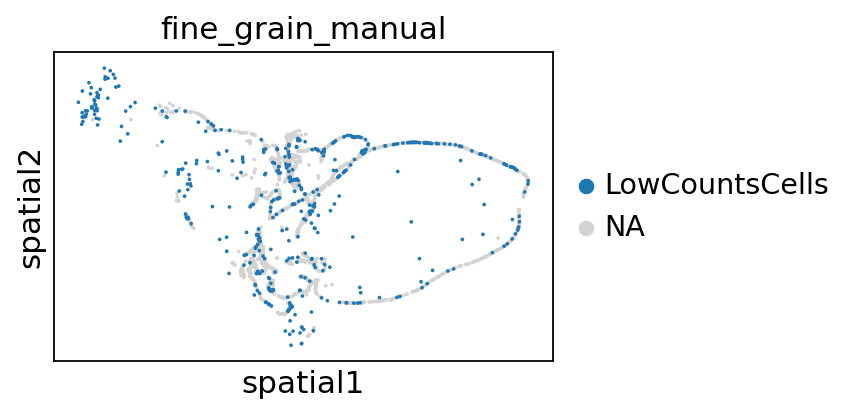

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


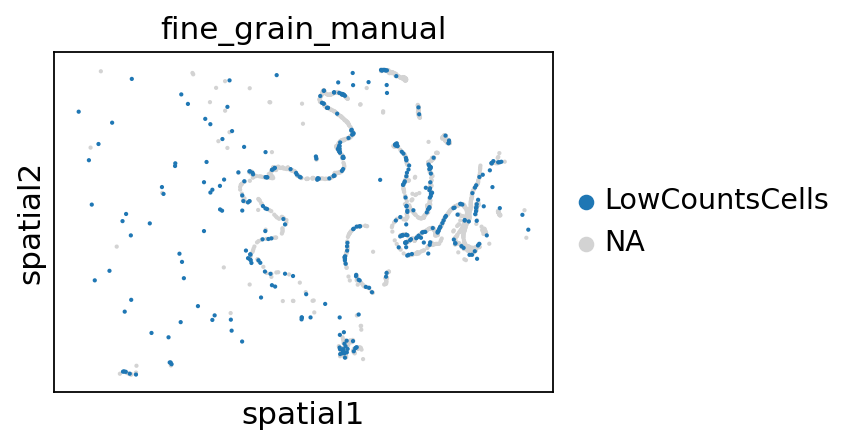

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


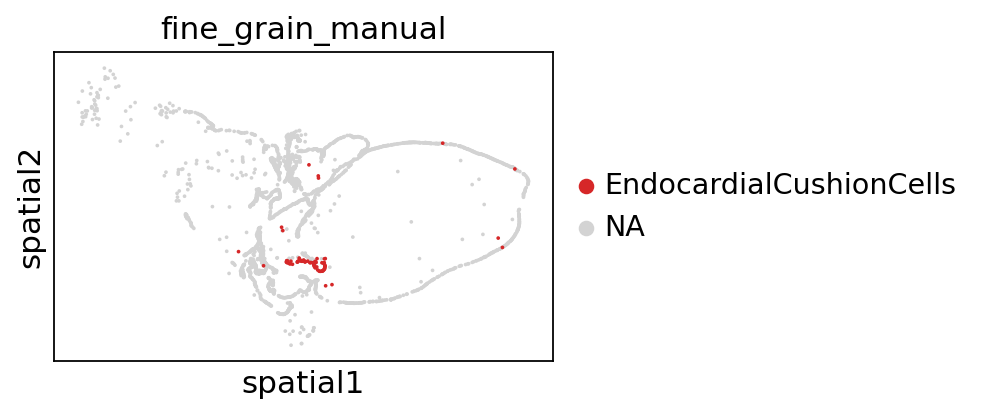

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


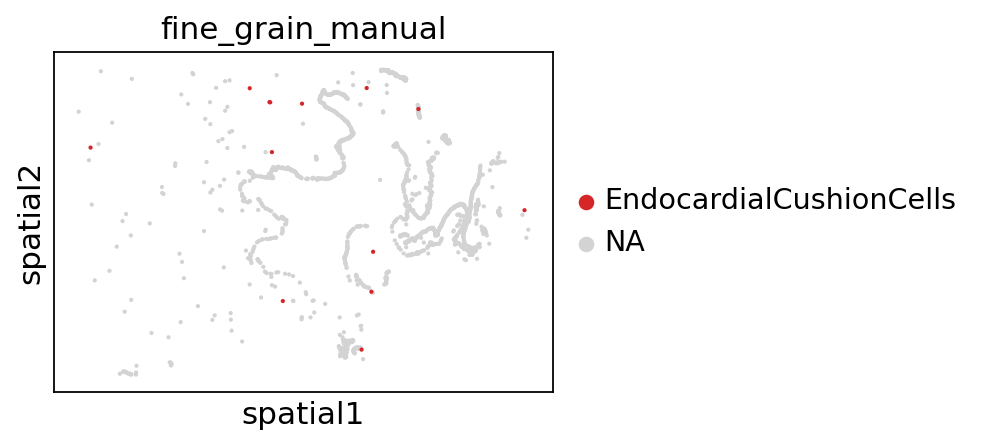

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


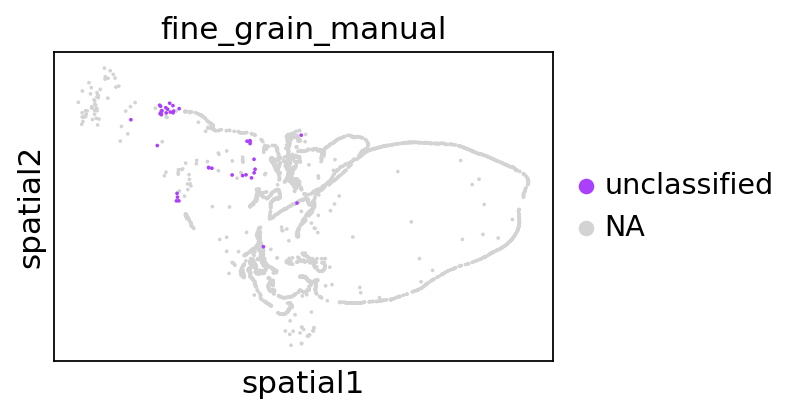

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


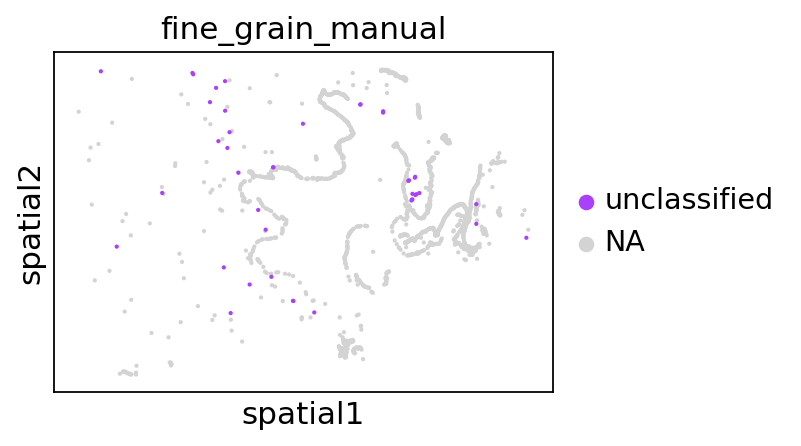

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


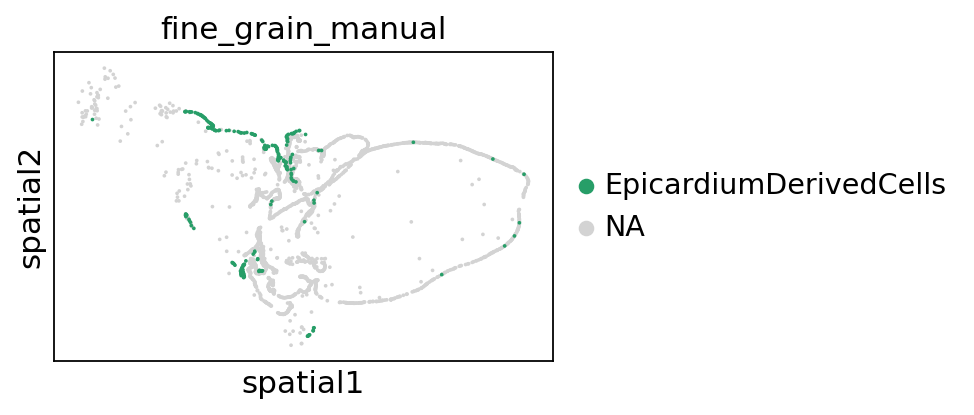

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


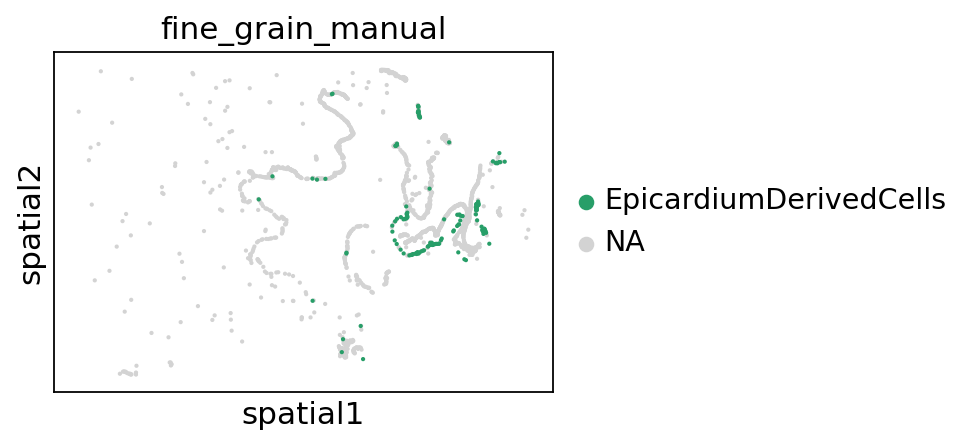

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


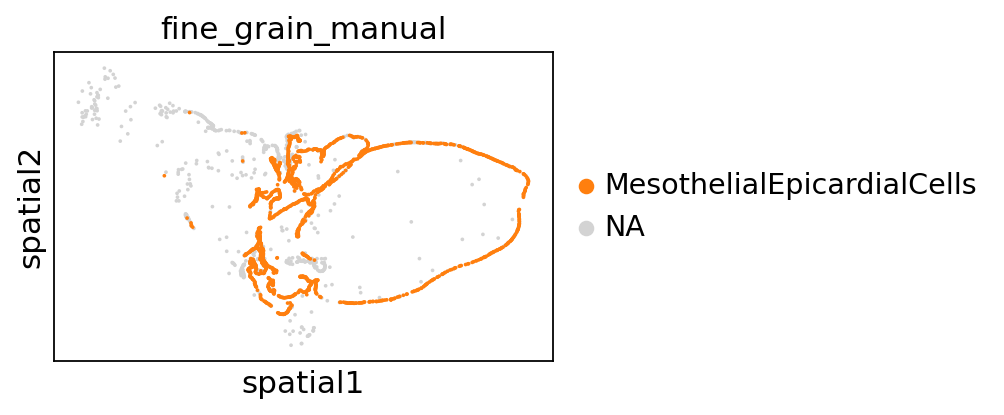

/tmp/ipykernel_2031645/2469648441.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],


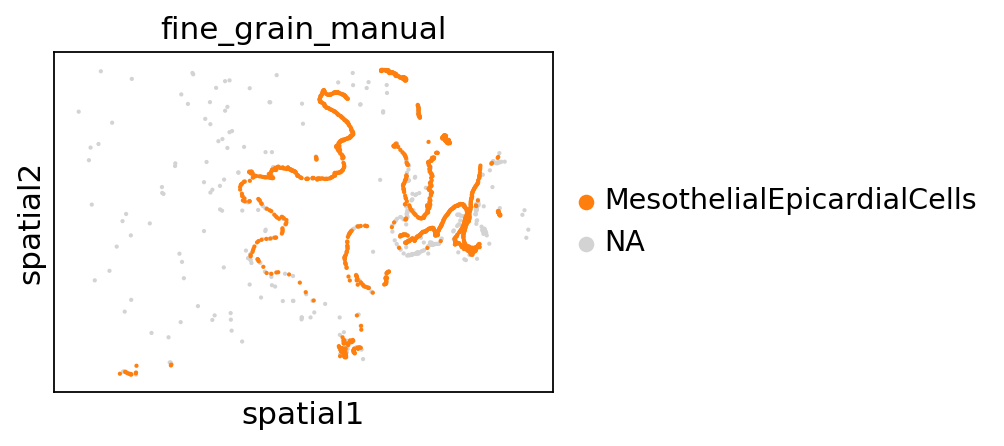

In [34]:
for celltype in set(adata.obs['fine_grain_manual']):
    for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
        slide = adata[adata.obs['tissue_block_id']==tissue_id]
        sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
                      spot_size=80,vmax='p100')